In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


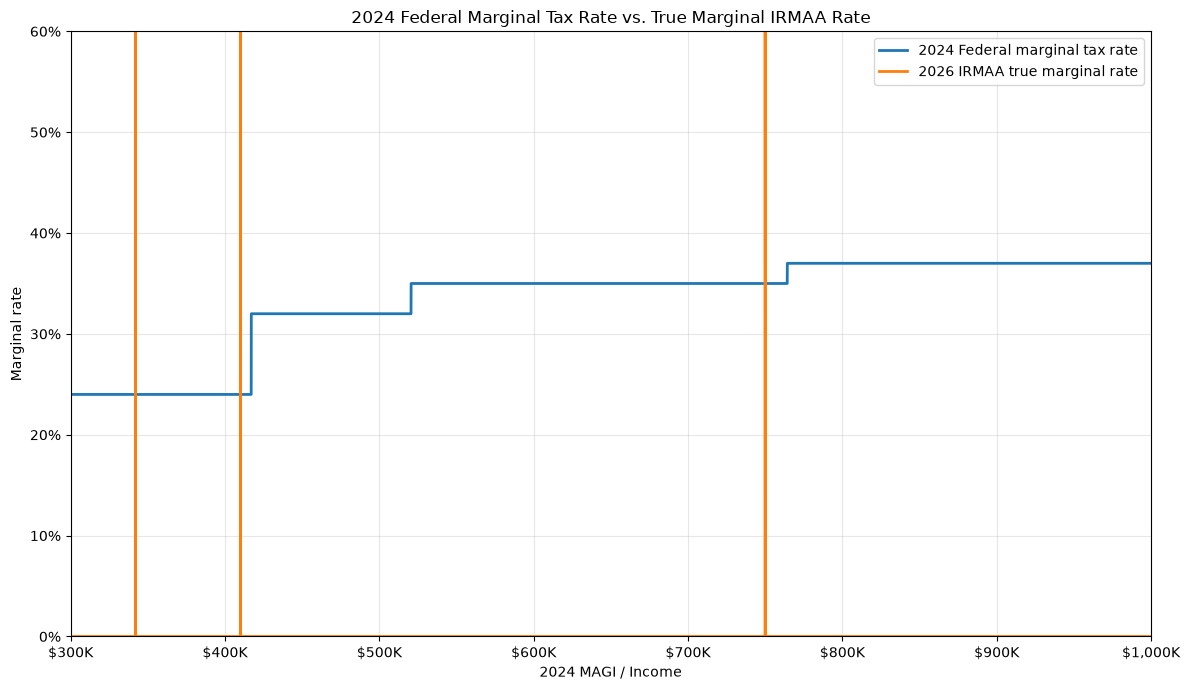

In [2]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2024 Federal marginal tax rate
# Married Filing Jointly, both spouses age 65+
#
# Additional standard deduction for two spouses age 65+:
# $1,950 x 2 = $3,900
# Base MFJ standard deduction: $29,200
# Total standard deduction: $33,100
# ------------------------------------------------------------

standard_deduction = 33100

# 2024 MFJ taxable-income brackets
tax_brackets = [
    (23200, 0.10),
    (94300, 0.12),
    (201050, 0.22),
    (383900, 0.24),
    (487450, 0.32),
    (731200, 0.35),
    (float("inf"), 0.37),
]

def federal_marginal_rate(income):
    taxable_income = max(0, income - standard_deduction)

    for threshold, rate in tax_brackets:
        if taxable_income <= threshold:
            return rate

    return 0.37


# ------------------------------------------------------------
# 2026 IRMAA
#
# Based on 2024 MAGI
# Married Filing Jointly
# Both spouses on Medicare
#
# These are the combined annual Part B + Part D increases
# for the couple when crossing each threshold.
#
# Threshold       Annual increase for couple
# $342,000        $3,470.40
# $410,000        $3,470.40
# $750,000        $1,161.60
# ------------------------------------------------------------

irmaa_thresholds = {
    342000: 3470.40,
    410000: 3470.40,
    750000: 1161.60,
}

def irmaa_marginal_rate(income):
    """
    True marginal IRMAA rate.

    At exactly $342,001, for example:
        $3,470.40 / $1 = 347,040%
    """

    for threshold, increase in irmaa_thresholds.items():
        if income == threshold + 1:
            return increase / 1

    return 0


# ------------------------------------------------------------
# Generate data
# ------------------------------------------------------------

incomes = list(range(300000, 1000001))

tax_rates = [
    federal_marginal_rate(income)
    for income in incomes
]

irmaa_rates = [
    irmaa_marginal_rate(income)
    for income in incomes
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    incomes,
    tax_rates,
    label="2024 Federal marginal tax rate",
    linewidth=2
)

ax.plot(
    incomes,
    irmaa_rates,
    label="2026 IRMAA true marginal rate",
    linewidth=2
)

ax.set_xlim(300000, 1000000)

# Change this to experiment with the vertical scale.
# 0.60 = 60%
ax.set_ylim(0, 0.60)

ax.set_xlabel("2024 MAGI / Income")
ax.set_ylabel("Marginal rate")

ax.set_title(
    "2024 Federal Marginal Tax Rate vs. True Marginal IRMAA Rate"
)

ax.grid(True, alpha=0.3)
ax.legend()

# Format X axis as dollars
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}K")
)

# Format Y axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, p: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

In [3]:
# Optional display tweaks can be applied here before rerendering.
# Example: ax.set_ylim(0, 0.60)
fig.tight_layout()
plt.show()